# Predicting heart disease using machine learning

Notebook content:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem Definition

> Given clinical parameters about a patient, can we predict wether or not they have heart disease?

## 2. Data


This dataset contains various health indicators and risk factors related to heart disease. Parameters such as age, gender, blood pressure, cholesterol levels, smoking habits, and exercise patterns have been collected to analyze heart disease risk and contribute to health research. The dataset can be used by healthcare professionals, researchers, and data analysts to examine trends related to heart disease, identify risk factors, and perform various health-related analyses.

Origin: https://www.kaggle.com/datasets/oktayrdeki/heart-disease

## 3. Evaluation

> If we can reach 95% accuracy at predicting wether or not a patient has heart disease during the proof of concept, weĺl pursue the project.

## 4. Features

Columns:
* Age: The individual's age.
* Gender: The individual's gender (Male or Female).
* Blood Pressure: The individual's blood pressure (systolic).
* Cholesterol Level: The individual's total cholesterol level.
* Exercise Habits: The individual's exercise habits (Low, Medium, High).
* Smoking: Whether the individual smokes or not (Yes or No).
* Family Heart Disease: Whether there is a family history of heart disease (Yes or No).
* Diabetes: Whether the individual has diabetes (Yes or No).
* BMI: The individual's body mass index.
* High Blood Pressure: Whether the individual has high blood pressure (Yes or No).
* Low HDL Cholesterol: Whether the individual has low HDL cholesterol (Yes or No).
* High LDL Cholesterol: Whether the individual has high LDL cholesterol (Yes or No).
* Alcohol Consumption: The individual's alcohol consumption level (None, Low, Medium, High).
* Stress Level: The individual's stress level (Low, Medium, High).
* Sleep Hours: The number of hours the individual sleeps.
* Sugar Consumption: The individual's sugar consumption level (Low, Medium, High).
* Triglyceride Level: The individual's triglyceride level.
* Fasting Blood Sugar: The individual's fasting blood sugar level.
* CRP Level: The C-reactive protein level (a marker of inflammation).
* Homocysteine Level: The individual's homocysteine level (an amino acid that affects blood vessel health).
* Heart Disease Status: The individual's heart disease status (Yes or No).

## Preparing the tools

I'm using pandas, Matplotlib and NumPy to analyse and manipule the data

In [56]:
# EDA (Exploratory Data Analysis)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

## Load data

In [57]:
df = pd.read_csv("datasets/heart_disease.csv")
df.shape # (rows, columns)

(10000, 21)

## Data Preparation

In [58]:
df = df.replace({
    "Male": 1,
    "Female": 0,
    
    "Yes": 1,
    "No": 0,

    "Low": 0,
    "Medium": 1,
    "High": 2
})

## Data Exploration

In [59]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,1,153.0,155.0,2,1,1,0,24.991591,1,...,0,2,1,7.633228,1,342.0,NaN,12.969246,12.387250,0
1,69.0,0,146.0,286.0,2,0,1,1,25.221799,0,...,0,1,2,8.744034,1,133.0,157.0,9.355389,19.298875,0
2,46.0,1,126.0,216.0,0,0,0,0,29.855447,0,...,1,0,0,4.440440,0,393.0,92.0,12.709873,11.230926,0
3,32.0,0,122.0,293.0,2,1,1,0,24.130477,1,...,1,0,2,5.249405,2,293.0,94.0,12.509046,5.961958,0
4,60.0,1,166.0,242.0,0,1,1,1,20.486289,1,...,0,0,2,7.030971,2,263.0,154.0,10.381259,8.153887,0


In [64]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [67]:
df["Gender"].value_counts()

Gender
1    5003
0    4978
Name: count, dtype: int64

In [71]:
df["Age"].mean()

np.float64(49.296259151539466)

In [73]:
pd.crosstab(df["Heart Disease Status"], df["Gender"])

Gender,0,1
Heart Disease Status,,
0,3948,4034
1,1030,969


<Axes: xlabel='Heart Disease Status'>

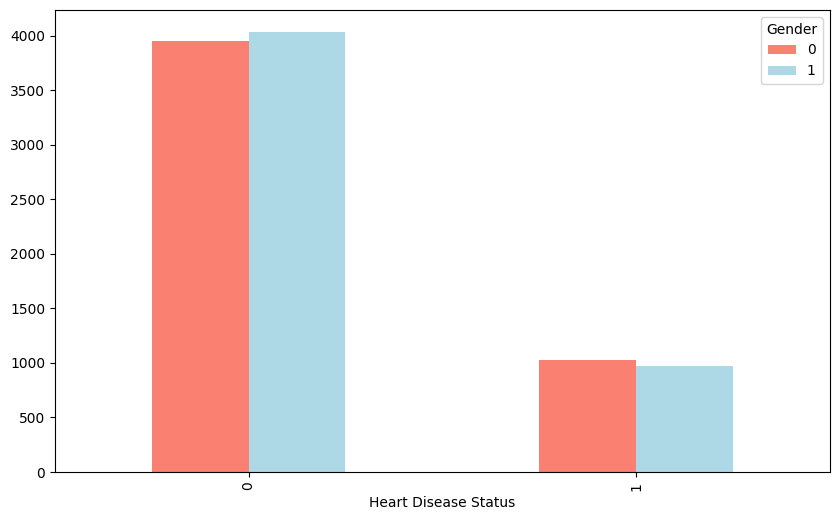

In [78]:
pd.crosstab(df["Heart Disease Status"], df["Gender"]).plot(kind="bar", color=["salmon", "lightblue"], figsize=(10,6))